# Gaussian Process Regression

This demo shows how to use the GaussianProcessRegressor class to regress the the dynamical system 

$y = x \sin(2 x) + \epsilon$  
$\frac{dy}{dx} = \sin(2 x) + 2 x \cos(2 x) + \epsilon$

Where the function and derivative observations have white noise with variance $\epsilon \sim \mathcal{N}(0, 0.2)$.

In [1]:
import sys 
import numpy as np
from IPython.display import IFrame
import matplotlib.pyplot as plt
%matplotlib inline  

from sklearn.metrics import mean_squared_error

sys.path.append("../../../gpder")
import gpder
from gpder.gaussian_process import GaussianProcessRegressor
from gpder.gaussian_process.kernels import GPKernel, GPKernelDerAware

from plotting_utils import plot_gp

In [2]:
def F(X, e=0.2):
    noise = np.random.normal(0, e, X.shape)
    return X * np.sin(2 * X) + noise

def dF(X, e=0.2):
    noise = np.random.normal(0, e, X.shape)
    return np.sin(2 * X) + 2 * X * np.cos(2 * X) + noise

In [3]:
np.random.seed(123)
X_lower, X_upper = -2*np.pi, 2*np.pi

# -- testing points -- #
X_test = np.linspace(X_lower, X_upper, 100).reshape(-1, 1)
dX_test = X_test

y_test_nonoise = F(X_test, e=0)
dy_test_nonoise = dF(dX_test, e=0)
y_test = F(X_test)
dy_test = dF(dX_test)

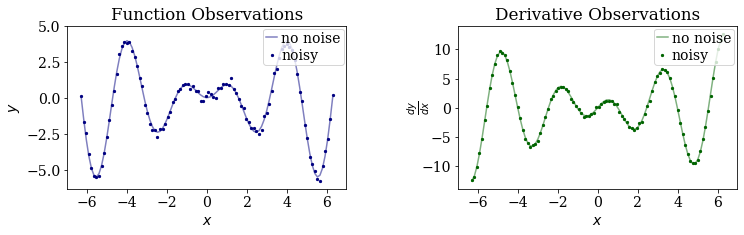

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = "14"

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
plt.subplots_adjust(wspace=0.4)

ax[0].plot(X_test, y_test_nonoise, alpha=0.5, color='navy', label='no noise')
ax[0].scatter(X_test, y_test, color='navy', s=5, label='noisy')
ax[0].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')
ax[0].set_yticks([-5, -2.5, 0, 2.5, 5])
ax[0].set_xticks([-6, -4, -2, 0, 2, 4, 6])
ax[0].set_title('Function Observations')
ax[0].tick_params(axis='both', which='major')

ax[1].plot(dX_test, dy_test_nonoise, alpha=0.5, color='darkgreen', label='no noise')
ax[1].scatter(dX_test, dy_test, color='darkgreen', s=5, label='noisy')
ax[1].set_xlabel(r'$x$')
ax[1].set_ylabel(r'$\frac{dy}{dx}$', labelpad=-10)
ax[1].set_yticks([-10, -5, 0, 5, 10])
ax[1].set_xticks([-6, -4, -2, 0, 2, 4, 6])
ax[1].set_title('Derivative Observations')
ax[1].tick_params(axis='both', which='major')

ax[0].legend(labelspacing=0.2, handlelength=0.8, 
             borderaxespad=0.2, handletextpad=0.3, borderpad=0.2,
             loc='upper right')
ax[1].legend(labelspacing=0.2, handlelength=0.8, 
             borderaxespad=0.2, handletextpad=0.3, borderpad=0.2,
             loc='upper right')
plt.show()

## Regular GPR

We perform five experiments to observe the function observarions. These experiments are used to train the GP regressor. 

In [5]:
# -- training points -- #
np.random.seed(123)
X_train = np.random.uniform(X_lower, X_upper, 5).reshape(-1, 1)
y_train = F(X_train)

Kernel:  1.5 * RBF(length_scale=0.5) + WhiteKernel(noise_level=0.2)
MSE :  5.287756862663273
Uncert :  110.8621115979189


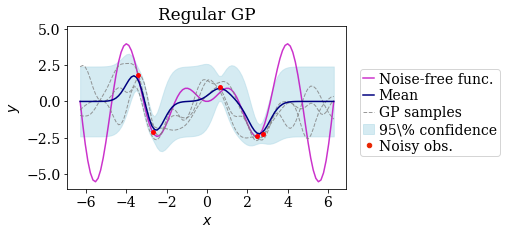

In [6]:
kernel = GPKernel(constant_value_bounds=(1e-1, 1.5), 
                  length_scale_bounds=(0.5, 1.5), 
                  noise_level_bounds=(1e-5, 0.2))

gp_regular = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30)
gp_regular.fit(X_train, y_train)
print("Kernel: ", gp_regular.kernel_)

y_pred, cov = gp_regular.predict(X_test.reshape(-1, 1), return_cov=True)
_, std = gp_regular.predict(X_test.reshape(-1, 1), return_std=True)

mse = mean_squared_error(y_test, y_pred)
print("MSE : ", mse)
print("Uncert : ", np.trace(cov))

plot_gp(gp_regular, X_test, y_test_nonoise, title='Regular GP')

## Derivative GPR

We now include derivative observations.  
For comparison, we use the same kernel hyperparameters that we used in the regular case. 

In [7]:
# -- training points -- #
dX_train = X_train
dy_train = dF(dX_train)

Kernel:  1.5 * DerivativeRBF(length_scale=0.5) + WhiteKernel_X(noise_level=0.2) + WhiteKernel_dX(noise_level=0.1)
 ----- Function obs ----- 
MSE :  4.7583447772875695
Uncert :  92.57830174319412
 
 ----- Derivative obs ----- 
MSE :  21.02175025529734
Uncert :  395.5641185129007


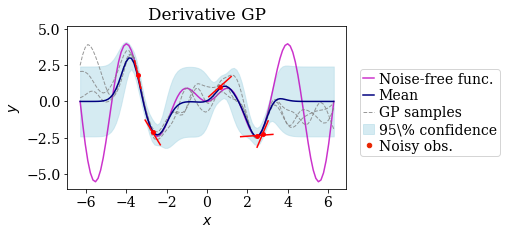

In [8]:
kernel = GPKernelDerAware(constant_value=gp_regular.kernel_.constant_value, 
                          constant_value_bounds="fixed",
                          length_scale=gp_regular.kernel_.length_scale, 
                          length_scale_bounds="fixed",
                          noise_level=gp_regular.kernel_.noise_level, 
                          noise_level_bounds="fixed",
                          noise_level_dX_bounds=(1e-3, 1e-1))
gp_deriv = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=30)
gp_deriv.fit(X_train, y_train, dX_train, dy_train)
print("Kernel: ", gp_deriv.kernel_)

y_pred, cov = gp_deriv.predict(X_test, return_cov=True)
_, std = gp_deriv.predict(X_test, return_std=True)
mse = mean_squared_error(y_test, y_pred)
print(" ----- Function obs ----- ")
print("MSE : ", mse)
print("Uncert : ", np.trace(cov))
print(" ")

dy_pred, dy_cov = gp_deriv.predict_der(X_test.reshape(-1, 1), return_cov=True)
_, dy_std = gp_deriv.predict_der(X_test.reshape(-1, 1), return_std=True)
dy_mse = mean_squared_error(dy_test, dy_pred)
print(" ----- Derivative obs ----- ")
print("MSE : ", dy_mse)
print("Uncert : ", np.trace(dy_cov))

plot_gp(gp_deriv, X_test, y_test_nonoise, title='Derivative GP', deriv=True)